In [25]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
import kagglehub
#adabosting
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.svm import LinearSVC


In [26]:
path = kagglehub.dataset_download("kshitizregmi/jobs-and-job-description")
df = pd.read_csv(f"{path}/job_title_des.csv")

Using Colab cache for faster access to the 'jobs-and-job-description' dataset.


In [27]:
df.head()

,Unnamed: 0,Job Title,Job Description
0,0,Flutter Developer,We are looking for hire experts flutter develo...
1,1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,4,Full Stack Developer,job responsibility full stack engineer – react...


In [28]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [29]:
df.dropna(inplace=True)

In [30]:
df.drop_duplicates(inplace=True)

In [31]:
Min_Samples = 30
job_counts = df["Job Title"].value_counts()
valid_jobs = job_counts[job_counts >= Min_Samples].index

df = df[df["Job Title"].isin(valid_jobs)].copy()

print(f"Selected {len(valid_jobs)} job titles dynamically:")
print(valid_jobs.tolist())
print(f"Total samples: {len(df)}")

Selected 15 job titles dynamically:
['JavaScript Developer', 'Java Developer', 'Software Engineer', 'Node js developer', 'iOS Developer', 'PHP Developer', 'Flutter Developer', 'DevOps Engineer', 'Django Developer', 'Machine Learning', 'Backend Developer', 'Network Administrator', 'Database Administrator', 'Full Stack Developer', 'Wordpress Developer']
Total samples: 2277


In [32]:
len(df["Job Title"])

2277

In [33]:
def clean_txt(text: str):
  text = str(text).lower()
  text = re.sub(r'[^a-z0-9\s+#.]',' ',text)
  text = re.sub(r'\s+',' ',text).strip()
  return text
df["clean_des"] = df['Job Description'].apply(clean_txt)

In [34]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)
x = vectorizer.fit_transform(df["clean_des"])
y = df["Job Title"]
model  = LogisticRegression(max_iter=1000,class_weight="balanced")
cv_score = cross_val_score(model,x,y,cv=5,scoring="f1_weighted")
print(cv_score)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))


[0.84137379 0.83342661 0.8325102  0.83502273 0.85025181]
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91   

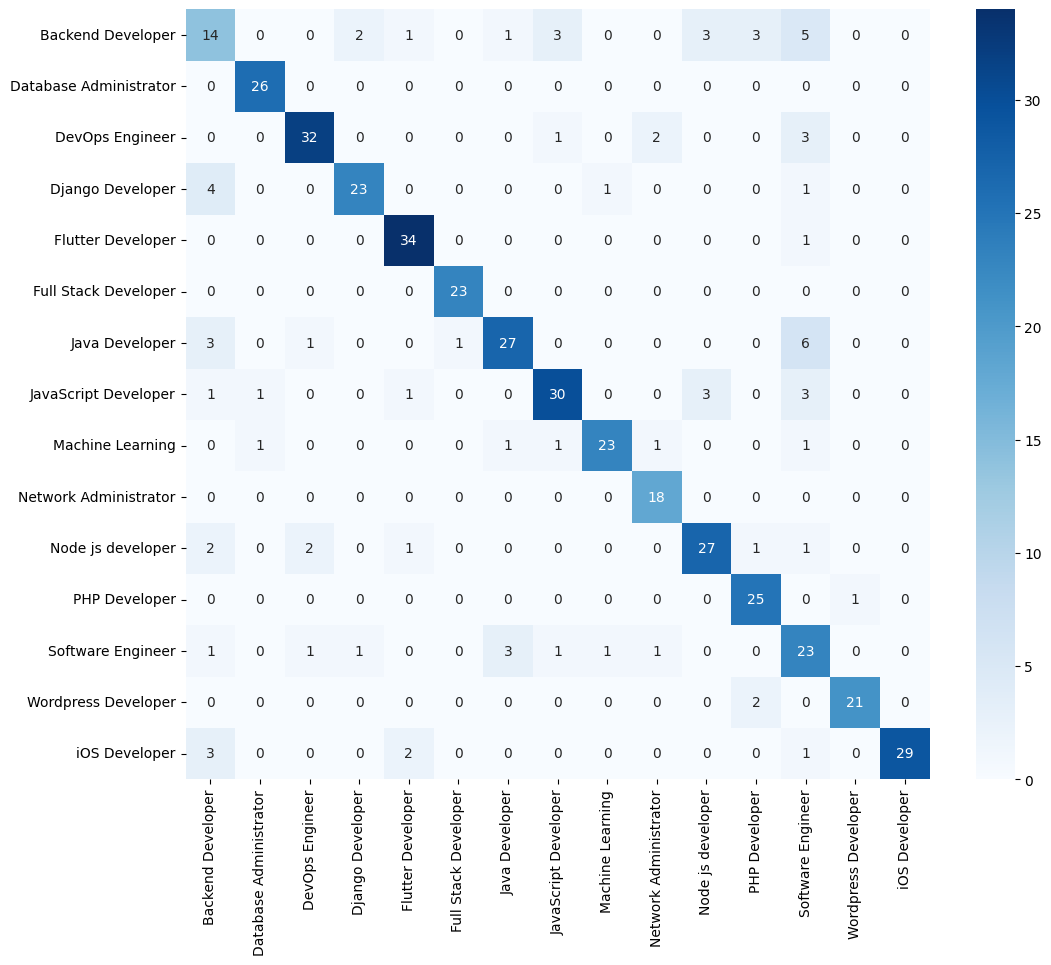

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_, cmap="Blues")
plt.xticks(rotation=90)
plt.show()

In [36]:
svm_model = SVC(class_weight="balanced", max_iter=2000)
svm_model.fit(x, y)

def predict_role_from_skills(skills: list[str]) -> str:
    text = " ".join(skills)
    cleaned = clean_txt(text)
    vector = vectorizer.transform([cleaned])
    return svm_model.predict(vector)[0]

print(predict_role_from_skills(["Python", "Django", "REST API"]))
print(predict_role_from_skills(["JavaScript", "React", "Node.js"]))

Django Developer
Node js developer


In [37]:
random_model =  RandomForestClassifier(class_weight="balanced")
random_scores = cross_val_score(svm_model, x, y, cv=5, scoring="f1_weighted")
print(f"radom Mean F1: {random_scores.mean():.3f}")
random_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

radom Mean F1: 0.831
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Devel

In [38]:
knn_model =  KNeighborsClassifier()
knn_scores = cross_val_score(svm_model, x, y, cv=5, scoring="f1_weighted")
print(f"knn Mean F1: {knn_scores.mean():.3f}")
knn_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

knn Mean F1: 0.831
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Develop

In [39]:
b_model =   BalancedRandomForestClassifier()
b_scores = cross_val_score(svm_model, x, y, cv=5, scoring="f1_weighted")
print(f"b Mean F1: {knn_scores.mean():.3f}")
knn_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

b Mean F1: 0.831
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Developer

In [40]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_scores = cross_val_score(svm_model, x, y, cv=5)
print(f"nb Mean F1: {nb_scores.mean():.3f}")
nb_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

nb Mean F1: 0.823
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Develope

In [41]:
ad_model =   AdaBoostClassifier()
ad_scores = cross_val_score(ad_model, x, y, cv=5, scoring="f1_weighted")
print(f"a Mean F1: {knn_scores.mean():.3f}")
ad_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

a Mean F1: 0.831
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Developer

In [42]:
svm_model = LinearSVC(class_weight="balanced", max_iter=2000)
svm_scores = cross_val_score(svm_model, x, y, cv=5, scoring="f1_weighted")
print(f"SVM Mean F1: {svm_scores.mean():.3f}")

# Fit the svm_model on the entire dataset after cross-validation
svm_model.fit(x, y)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

SVM Mean F1: 0.853
                        precision    recall  f1-score   support

     Backend Developer       0.50      0.44      0.47        32
Database Administrator       0.93      1.00      0.96        26
       DevOps Engineer       0.89      0.84      0.86        38
      Django Developer       0.88      0.79      0.84        29
     Flutter Developer       0.87      0.97      0.92        35
  Full Stack Developer       0.96      1.00      0.98        23
        Java Developer       0.84      0.71      0.77        38
  JavaScript Developer       0.83      0.77      0.80        39
      Machine Learning       0.92      0.82      0.87        28
 Network Administrator       0.82      1.00      0.90        18
     Node js developer       0.82      0.79      0.81        34
         PHP Developer       0.81      0.96      0.88        26
     Software Engineer       0.51      0.72      0.60        32
   Wordpress Developer       0.95      0.91      0.93        23
         iOS Develop

In [43]:
import joblib
import os

os.makedirs("ml_engine/artifacts", exist_ok=True)
joblib.dump(svm_model, "ml_engine/artifacts/role_model.pkl")
joblib.dump(vectorizer, "ml_engine/artifacts/vectorizer.pkl")

['ml_engine/artifacts/vectorizer.pkl']

In [44]:
def predict_role(cv_json: dict)  :
    skills = cv_json.get("skills", [])
    if not skills:
        raise ValueError("CV_JSON must contain a non-empty 'skills' list.")

    text = " ".join(skills)
    cleaned = clean_txt(text)
    vector = vectorizer.transform([cleaned])

    predicted_role = svm_model.predict(vector)[0]

    return {
        "predicted_role": predicted_role,
        "skills_used": skills
    }


test_cv = {"skills": ["Python", "Flask", "SQL"]}
print(predict_role(test_cv))

{'predicted_role': 'Django Developer', 'skills_used': ['Python', 'Flask', 'SQL']}
